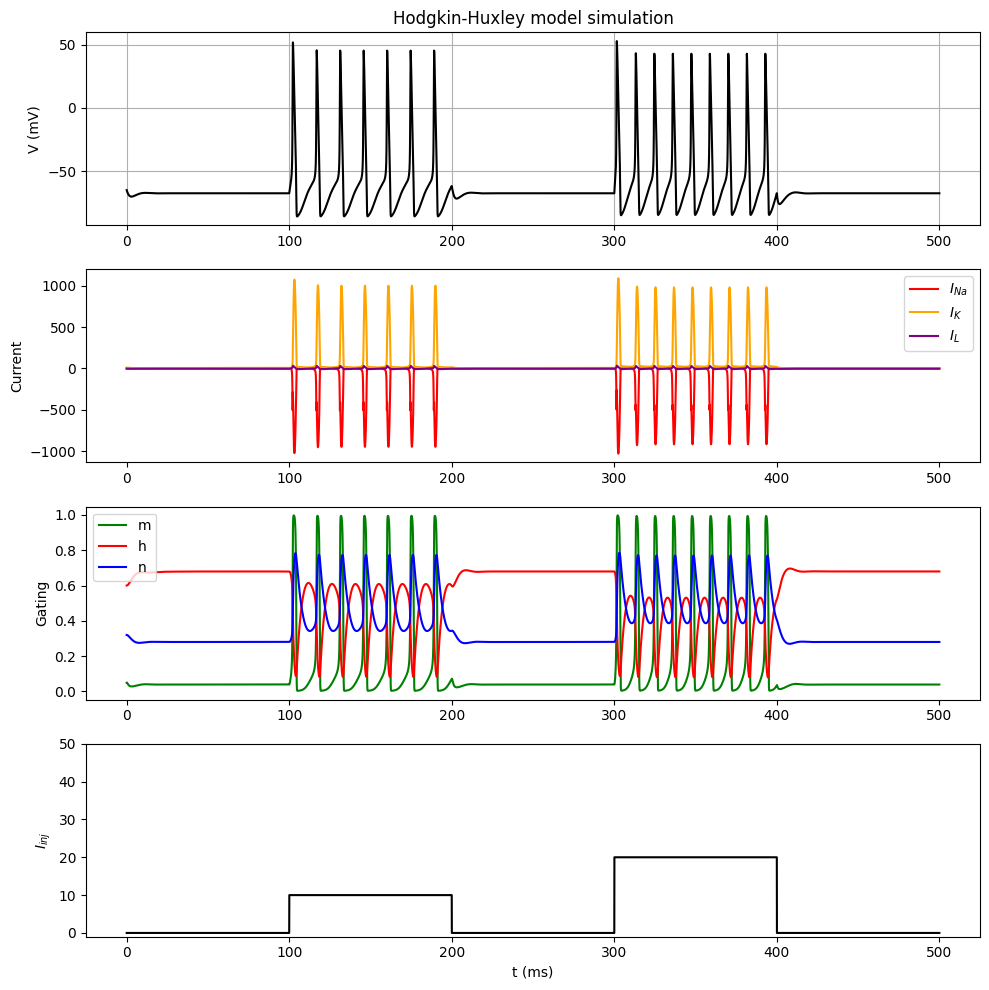

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# The Parameters (all these values are from squid neuron at ~6.3 degrees C, it is different at other temperatures and in other species))
Cm= 1
G_Na= 120
G_K= 36
G_L= 0.3
E_Na = 60.0
E_K = -88.0
E_L = -54.387

# Gating variables
def alpha_n(V):
    return 0.01*(V + 55)/(1 - np.exp(-(V + 55)/10))
def beta_n(V):
    return 0.125*np.exp(-(V+65)/80)
def alpha_m(V):
    return 0.1*(V + 40)/(1 - np.exp(-(V + 40)/10))
def beta_m(V):
    return 4.0*np.exp(-(V + 65)/18)
def alpha_h(V):
    return 0.07*np.exp(-(V + 65)/20)
def beta_h(V):
    return 1/(1 + np.exp(-(V + 35)/10))

# Current eq's
def I_Na(V, m, h):
    return G_Na * (m**3) * h * (V - E_Na)
def I_K(V, n):
    return G_K * (n**4) * (V - E_K)
def I_L(V):
    return G_L * (V - E_L)  

# Time
t= np.arange(0, 500, 0.01)

# Input current
def I_inj(t):
    period=4
    switch=2
    x= t%period
    if 100<t<200:
        if x<switch:
            return 10
        else:  
            return 10
    
    elif 300<t<400:
        if x<switch:
            return 20
        else:  
            return 20
    else:
        return 0

# Differential equations
def deffeq(X, t):
    V, m, h, n = X

    dVdt = (I_inj(t) - I_Na(V, m, h) - I_K(V, n) - I_L(V)) / Cm
    dmdt = alpha_m(V) * (1 - m) - beta_m(V) * m
    dhdt = alpha_h(V) * (1 - h) - beta_h(V) * h
    dndt = alpha_n(V) * (1 - n) - beta_n(V) * n

    return [dVdt, dmdt, dhdt, dndt]

# Solve ODE
X = odeint(deffeq, [-65, 0.05, 0.6, 0.32], t)
V = X[:, 0]
m = X[:, 1]
h = X[:, 2]
n = X[:, 3]

# Currents
ina = I_Na(V, m, h)
ik = I_K(V, n)
il = I_L(V)

# Plotting

plt.figure(figsize=(10, 10))

plt.subplot(4, 1, 1)
plt.title("Hodgkin-Huxley model simulation")
plt.plot(t, V, 'k')
plt.ylabel("V (mV)")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(t, ina, 'red', label='$I_{Na}$')
plt.plot(t, ik, 'orange', label='$I_K$')
plt.plot(t, il, 'purple', label='$I_L$')
plt.ylabel("Current")
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(t, m, 'g', label='m')
plt.plot(t, h, 'r', label='h')
plt.plot(t, n, 'b', label='n')
plt.ylabel("Gating")
plt.legend()

I = np.array([I_inj(tt) for tt in t])
plt.subplot(4, 1, 4)
plt.plot(t, I, 'k')
plt.xlabel("t (ms)")
plt.ylabel("$I_{inj}$")
plt.ylim(-1, 50)

plt.tight_layout()
plt.show()

In [2]:
def count_spikes(V, threshold=0):
    spikes = 0
    for i in range(1, len(V)):
        if V[i-1] < threshold and V[i] >= threshold:
            spikes += 1
    return spikes


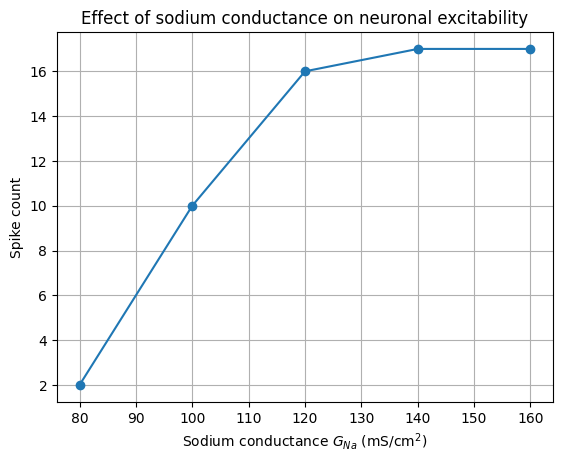

In [ ]:
# Sodium conductance sweep

G_Na_values = np.arange(80, 161, 20)  # mS/cm^2
spike_counts = []

for gna in G_Na_values:
    G_Na = gna  # override sodium conductance
    
    X = odeint(deffeq, [-65, 0.05, 0.6, 0.32], t)
    V = X[:, 0]
    
    spikes = count_spikes(V)
    spike_counts.append(spikes)

plt.figure()
plt.plot(G_Na_values, spike_counts, marker='o')
plt.xlabel("Sodium conductance $G_{Na}$ (mS/cm$^2$)")
plt.ylabel("Spike count")
plt.title("Effect of sodium conductance on neuronal excitability")
plt.grid(True)
plt.show()
